# Keşifçi Veri Analizi (EDA)
**Kutay Kalay** · SoftITo Yapay Zeka · 18.09.2026

Bu çalışmada 1000 müşterilik sentetik bir veri seti üretip içine bilerek "kirli veri" ekliyorum,
sonra adım adım bu sorunları tespit edip veriyi tanımaya çalışıyorum.

## 1. Hazırlık ve Ortam Ayarları
- Kütüphaneleri içe aktarıyorum.
- Grafik stilini tek yerden ayarlıyorum ki tüm grafikler aynı görünsün.
- `seed` sabitliyorum: rastgele üretilen veri her çalıştırmada aynı çıksın.
- Pandas görüntü ayarları: tüm sütunlar görünsün, ondalıklar 2 hane olsun.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)

SEED = 7
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Sentetik Veri Setinin Oluşturulması
1000 müşteri için yaş, gelir, şehir, abonelik tipi, kayıt tarihi, aylık harcama, memnuniyet puanı ve churn üretiyorum.

- Gelir gerçek hayatta sağa çarpık olduğu için **lognormal** dağılımdan üretiyorum.
- Aylık harcamayı gelire bağlı kurdum ki korelasyon analizinde anlamlı bir ilişki görebileyim.
- Şehir listesine bilerek aynı şehrin farklı yazımlarını koydum (`İstanbul` / `istanbul`, `Ankara` / `ANKARA` / `" Ankara "`).

In [2]:
N = 1000

sehir_secenekleri = ["İstanbul", "istanbul", "Ankara", "ANKARA", " Ankara ", "İzmir", "izmir ", "Bursa", "Antalya"]

yas = rng.integers(18, 71, N).astype(float)
gelir = rng.lognormal(mean=10.4, sigma=0.5, size=N).round(0)
aylik_harcama = (gelir * 0.06 + rng.normal(0, 400, N)).clip(min=100).round(2)

musteriler = pd.DataFrame({
    "musteri_id": np.arange(1001, 1001 + N),
    "yas": yas,
    "gelir": gelir,
    "sehir": rng.choice(sehir_secenekleri, N),
    "abonelik_tipi": rng.choice(["Standart", "Gold", "Platinum"], N, p=[0.55, 0.30, 0.15]),
    "kayit_tarihi": pd.Timestamp("2023-01-01") + pd.to_timedelta(rng.integers(0, 1000, N), unit="D"),
    "aylik_harcama": aylik_harcama,
    "memnuniyet_puani": rng.choice([1, 2, 3, 4, 5], N, p=[0.08, 0.12, 0.25, 0.30, 0.25]).astype(float),
    "churn": rng.choice([0, 1], N, p=[0.78, 0.22]),
})

musteriler.head()

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1001,68.00,47738.00,Ankara,Standart,2025-04-05,3201.45,3.00,1
1,1002,51.00,49523.00,Bursa,Gold,2024-04-04,2957.49,1.00,0
2,1003,54.00,20320.00,istanbul,Standart,2024-01-14,1150.38,2.00,0
3,1004,65.00,16396.00,istanbul,Gold,2024-08-31,641.08,4.00,0
4,1005,48.00,27518.00,Bursa,Platinum,2024-05-28,1288.41,3.00,0


## 3. Kasıtlı "Kirli Veri" Enjeksiyonu
Gerçek veri hiçbir zaman temiz gelmez. Temizleme adımlarını denemek için şunları ekliyorum:
- `gelir`, `yas`, `memnuniyet_puani` sütunlarına **eksik değer**
- `gelir` sütununa birkaç **aşırı uç değer** (outlier)
- `yas` sütununa **mantıksız değerler** (-5, 150 gibi)
- birkaç **yinelenen satır**

In [3]:
def rastgele_index(adet):
    return rng.choice(musteriler.index, size=adet, replace=False)

# eksik değerler
musteriler.loc[rastgele_index(60), "gelir"] = np.nan
musteriler.loc[rastgele_index(35), "yas"] = np.nan
musteriler.loc[rastgele_index(45), "memnuniyet_puani"] = np.nan

# gelirde aşırı uç değerler
musteriler.loc[rastgele_index(8), "gelir"] = rng.integers(400_000, 1_000_000, 8)

# mantıksız yaşlar
musteriler.loc[rastgele_index(4), "yas"] = [-5, -1, 150, 132]

# yinelenen satırlar
kopyalar = musteriler.sample(12, random_state=SEED)
musteriler = pd.concat([musteriler, kopyalar], ignore_index=True)

print("Kirli veri eklendikten sonra boyut:", musteriler.shape)

Kirli veri eklendikten sonra boyut: (1012, 9)


## 4. Veri Setine Genel Bakış

In [4]:
satir, sutun = musteriler.shape
print(f"{satir} satır, {sutun} sütun")

1012 satır, 9 sütun


In [5]:
musteriler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   musteri_id        1012 non-null   int64         
 1   yas               977 non-null    float64       
 2   gelir             952 non-null    float64       
 3   sehir             1012 non-null   object        
 4   abonelik_tipi     1012 non-null   object        
 5   kayit_tarihi      1012 non-null   datetime64[ns]
 6   aylik_harcama     1012 non-null   float64       
 7   memnuniyet_puani  967 non-null    float64       
 8   churn             1012 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 71.3+ KB


In [6]:
musteriler.head(3)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
0,1001,68.00,47738.00,Ankara,Standart,2025-04-05,3201.45,3.00,1
1,1002,51.00,49523.00,Bursa,Gold,2024-04-04,2957.49,1.00,0
2,1003,54.00,20320.00,istanbul,Standart,2024-01-14,1150.38,2.00,0


In [7]:
musteriler.tail(3)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
1009,1171,69.00,27567.00,İzmir,Platinum,2025-02-15,792.87,4.00,0
1010,1025,56.00,31789.00,İstanbul,Standart,2023-11-30,2213.42,4.00,0
1011,1243,63.00,25567.00,Bursa,Standart,2025-08-20,1269.05,3.00,0


In [8]:
musteriler.sample(5, random_state=SEED)

,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
113,1114,61.00,31966.00,Ankara,Standart,2025-01-03,1901.64,2.00,0
795,1796,26.00,66107.00,İstanbul,Gold,2024-02-27,3805.64,3.00,0
817,1818,32.00,37393.00,izmir,Standart,2024-02-02,1937.25,3.00,0
510,1511,63.00,21748.00,ANKARA,Standart,2023-03-06,958.00,3.00,1
492,1493,62.00,15008.00,ANKARA,Standart,2024-08-23,1160.46,3.00,0


## 5. Eksik Değer Analizi
Her sütun için veri tipi, eksik sayısı, eksik yüzdesi ve benzersiz değer sayısını tek tabloda topluyorum.

In [9]:
eksik_tablo = pd.DataFrame({
    "tip": musteriler.dtypes,
    "eksik": musteriler.isna().sum(),
    "eksik_%": musteriler.isna().mean() * 100,
    "benzersiz": musteriler.nunique(),
}).sort_values("eksik", ascending=False)

eksik_tablo

,tip,eksik,eksik_%,benzersiz
gelir,float64,60,5.93,936
memnuniyet_puani,float64,45,4.45,5
yas,float64,35,3.46,57
musteri_id,int64,0,0.00,1000
sehir,object,0,0.00,9
abonelik_tipi,object,0,0.00,3
kayit_tarihi,datetime64[ns],0,0.00,632
aylik_harcama,float64,0,0.00,997
churn,int64,0,0.00,2


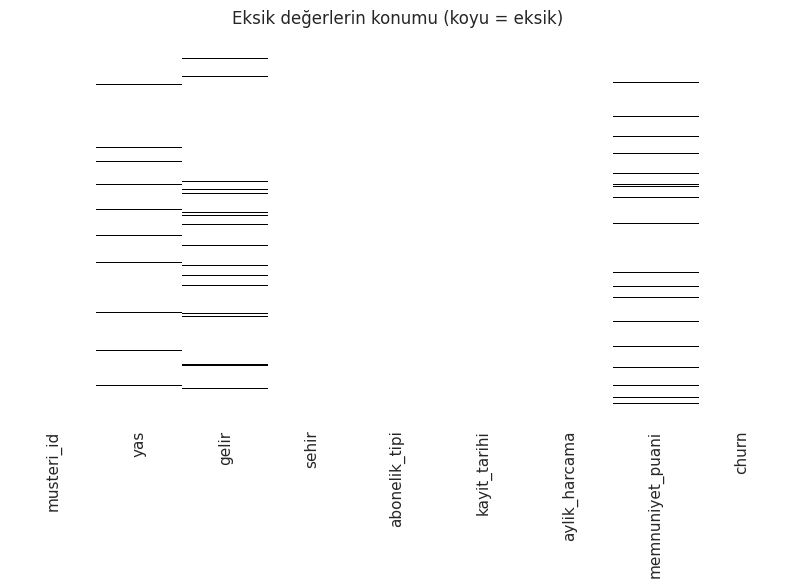

In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(musteriler.isna(), cbar=False, yticklabels=False, cmap="Greys")
plt.title("Eksik değerlerin konumu (koyu = eksik)")
plt.show()

## 6. Yinelenen Kayıtların Tespiti

In [11]:
tekrar_sayisi = musteriler.duplicated().sum()
print("Birebir aynı satır sayısı:", tekrar_sayisi)

musteriler[musteriler.duplicated(keep=False)].sort_values("musteri_id").head(6)

Birebir aynı satır sayısı: 12


,musteri_id,yas,gelir,sehir,abonelik_tipi,kayit_tarihi,aylik_harcama,memnuniyet_puani,churn
24,1025,56.00,31789.00,İstanbul,Standart,2023-11-30,2213.42,4.00,0
1010,1025,56.00,31789.00,İstanbul,Standart,2023-11-30,2213.42,4.00,0
1007,1095,30.00,31205.00,Antalya,Standart,2023-05-21,1675.19,3.00,1
94,1095,30.00,31205.00,Antalya,Standart,2023-05-21,1675.19,3.00,1
170,1171,69.00,27567.00,İzmir,Platinum,2025-02-15,792.87,4.00,0
1009,1171,69.00,27567.00,İzmir,Platinum,2025-02-15,792.87,4.00,0


In [12]:
# tekrarları temizliyorum
musteriler = musteriler.drop_duplicates().reset_index(drop=True)
print("Temizlik sonrası boyut:", musteriler.shape)

Temizlik sonrası boyut: (1000, 9)


## 7. Kategorik Veri Temizliği
Önce şehir sütunundaki farklı yazımları görüyorum, sonra hepsini küçük harfe çevirip boşlukları siliyorum.

⚠️ Türkçe'de `"İ".lower()` Python'da `"i̇"` (noktalı i + birleşik nokta) üretir. Bu yüzden `İ` harfini önce elle `i` yapıyorum.

In [13]:
musteriler["sehir"].value_counts()

,count
sehir,
İstanbul,118
istanbul,117
ANKARA,116
izmir,114
İzmir,109
Ankara,107
Ankara,107
Antalya,107
Bursa,105


In [14]:
musteriler["sehir"] = (
    musteriler["sehir"]
    .str.replace("İ", "i")
    .str.lower()
    .str.strip()
)

musteriler["sehir"].value_counts()

,count
sehir,
ankara,330
istanbul,235
izmir,223
antalya,107
bursa,105


## 8. Mantık Dışı (Anomali) Değerlerin Tespiti

In [15]:
anormal_yas = musteriler[(musteriler["yas"] < 0) | (musteriler["yas"] > 100)]
print(f"{len(anormal_yas)} müşterinin yaşı gerçekçi değil:")
anormal_yas[["musteri_id", "yas"]]

4 müşterinin yaşı gerçekçi değil:


,musteri_id,yas
309,1310,-1.00
374,1375,-5.00
659,1660,132.00
904,1905,150.00


In [16]:
# bu değerleri geçersiz sayıp eksik (NaN) yapıyorum
musteriler.loc[anormal_yas.index, "yas"] = np.nan
musteriler["yas"].describe()

,yas
count,961.00
mean,44.61
std,15.30
min,18.00
25%,31.00
50%,45.00
75%,58.00
max,70.00


## 9. Betimsel İstatistikler

In [17]:
sayisal = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]

betimsel = musteriler[sayisal].describe().T
betimsel["medyan"] = musteriler[sayisal].median()
betimsel["carpiklik"] = musteriler[sayisal].skew()
betimsel["basiklik"] = musteriler[sayisal].kurt()
betimsel

,count,mean,std,min,25%,50%,75%,max,medyan,carpiklik,basiklik
yas,961.00,44.61,15.30,18.00,31.00,45.00,58.00,70.00,45.00,-0.04,-1.24
gelir,940.00,42429.53,65062.03,8024.00,23345.50,32177.50,45989.75,979160.00,32177.50,10.41,123.12
aylik_harcama,1000.00,2217.39,1269.44,100.00,1358.40,1957.63,2802.59,8473.96,1957.63,1.44,3.13
memnuniyet_puani,955.00,3.52,1.25,1.00,3.00,4.00,5.00,5.00,4.00,-0.50,-0.70


**Hatırlatma:**
- Çarpıklık ≈ 0 → simetrik, > 0 → sağa çarpık (uzun kuyruk sağda), < 0 → sola çarpık
- Basıklık > 0 → normal dağılıma göre daha sivri, kuyrukları kalın (uç değer bolluğu)

## 10. Dağılım Görselleştirmeleri

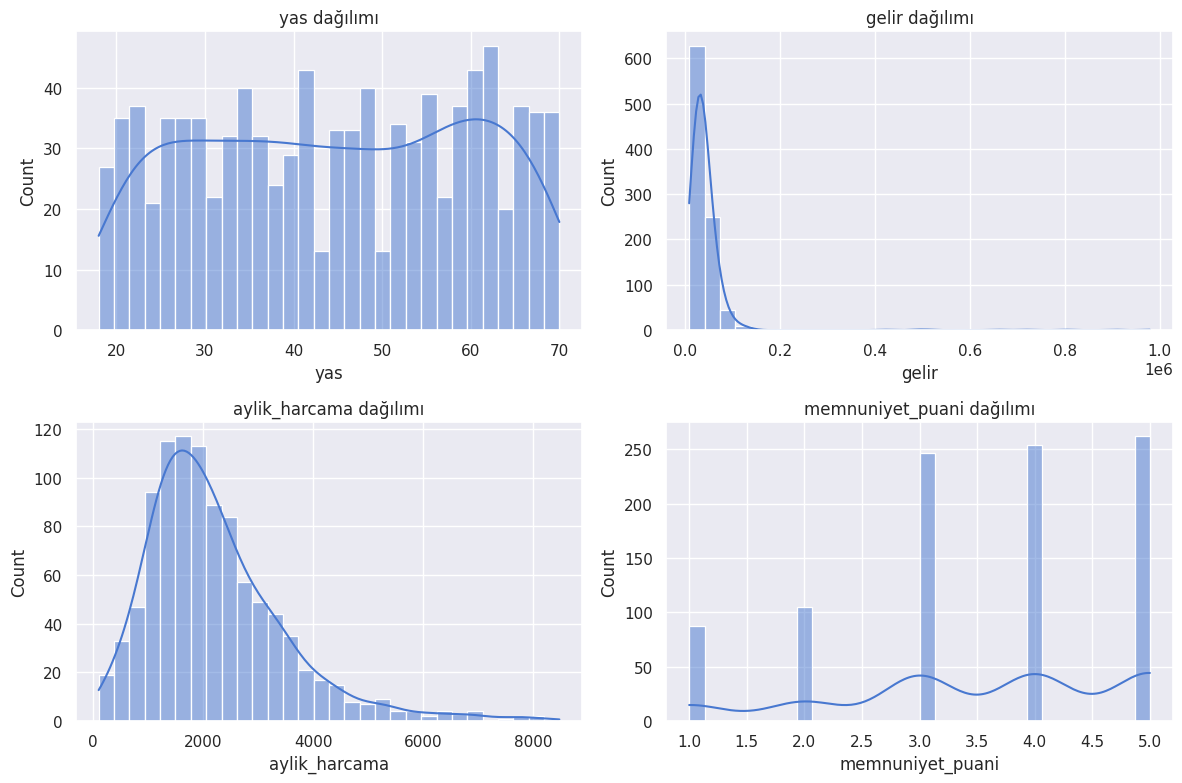

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), sayisal):
    sns.histplot(musteriler[col].dropna(), kde=True, bins=30, ax=ax)
    ax.set_title(f"{col} dağılımı")
plt.tight_layout()
plt.show()

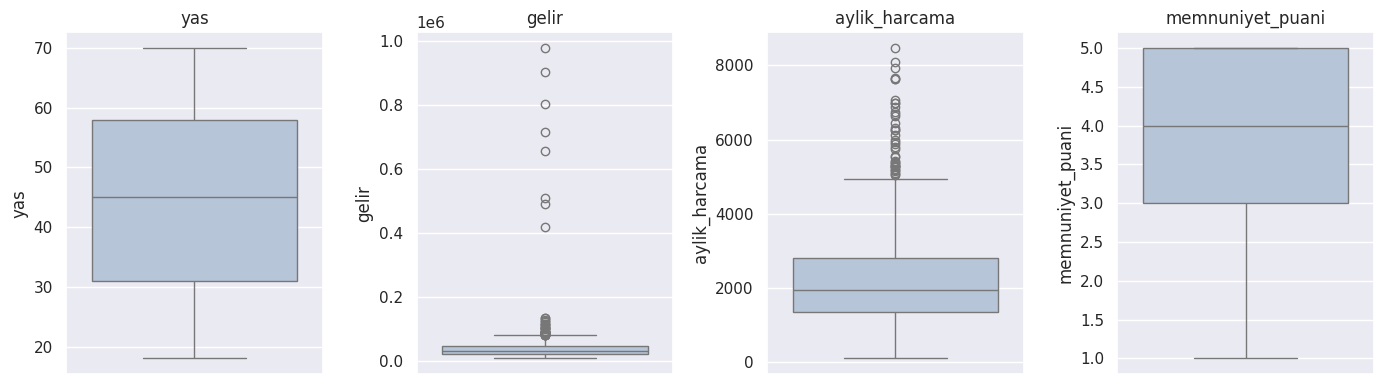

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, sayisal):
    sns.boxplot(y=musteriler[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [20]:
# IQR yöntemiyle gelirdeki aykırı değer sayısı
q1, q3 = musteriler["gelir"].quantile([0.25, 0.75])
iqr = q3 - q1
alt, ust = q1 - 1.5 * iqr, q3 + 1.5 * iqr
aykiri = musteriler[(musteriler["gelir"] < alt) | (musteriler["gelir"] > ust)]
print(f"Gelir için sınırlar: {alt:,.0f} – {ust:,.0f}")
print("Aykırı gözlem sayısı:", len(aykiri))

Gelir için sınırlar: -10,621 – 79,956
Aykırı gözlem sayısı: 44


## 11. Kategorik Değişken Analizi

In [21]:
kategorik = ["sehir", "abonelik_tipi", "memnuniyet_puani", "churn"]

for col in kategorik:
    oranlar = musteriler[col].value_counts(normalize=True, dropna=False).mul(100).round(1)
    print(f"--- {col} (%) ---")
    print(oranlar.to_string(), end="\n\n")

--- sehir (%) ---
sehir
ankara     33.00
istanbul   23.50
izmir      22.30
antalya    10.70
bursa      10.50

--- abonelik_tipi (%) ---
abonelik_tipi
Standart   55.90
Gold       29.10
Platinum   15.00

--- memnuniyet_puani (%) ---
memnuniyet_puani
5.00   26.20
4.00   25.40
3.00   24.70
2.00   10.50
1.00    8.70
NaN     4.50

--- churn (%) ---
churn
0   80.00
1   20.00



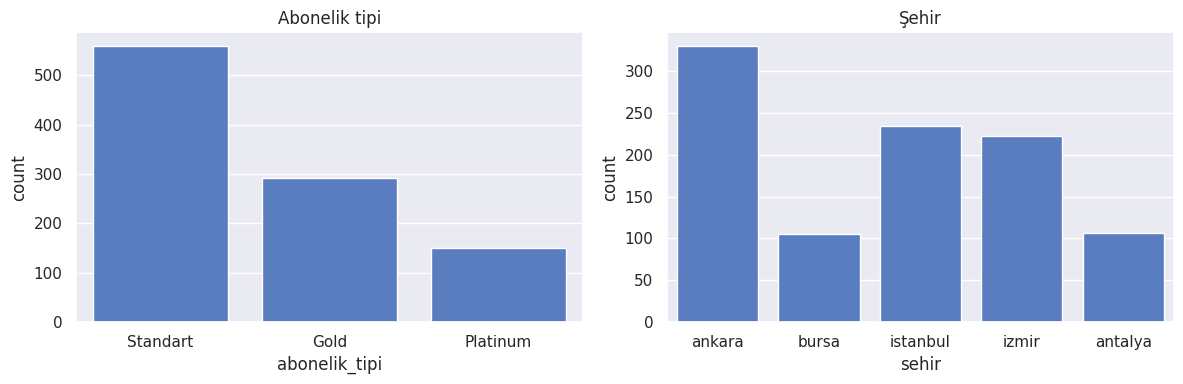

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=musteriler, x="abonelik_tipi", ax=axes[0])
axes[0].set_title("Abonelik tipi")
sns.countplot(data=musteriler, x="sehir", ax=axes[1])
axes[1].set_title("Şehir")
plt.tight_layout()
plt.show()

## 12. Korelasyon Analizi

In [23]:
korelasyon = musteriler[sayisal + ["churn"]].corr()
korelasyon

,yas,gelir,aylik_harcama,memnuniyet_puani,churn
yas,1.00,0.03,-0.04,-0.02,0.03
gelir,0.03,1.00,0.26,-0.01,-0.03
aylik_harcama,-0.04,0.26,1.00,-0.04,0.00
memnuniyet_puani,-0.02,-0.01,-0.04,1.00,0.03
churn,0.03,-0.03,0.00,0.03,1.00


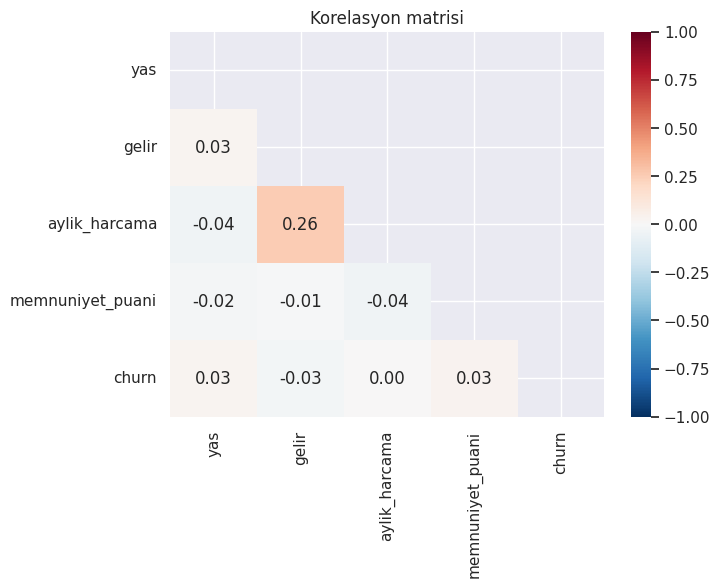

In [24]:
maske = np.triu(np.ones_like(korelasyon, dtype=bool))
plt.figure(figsize=(7, 5))
sns.heatmap(korelasyon, mask=maske, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Korelasyon matrisi")
plt.show()

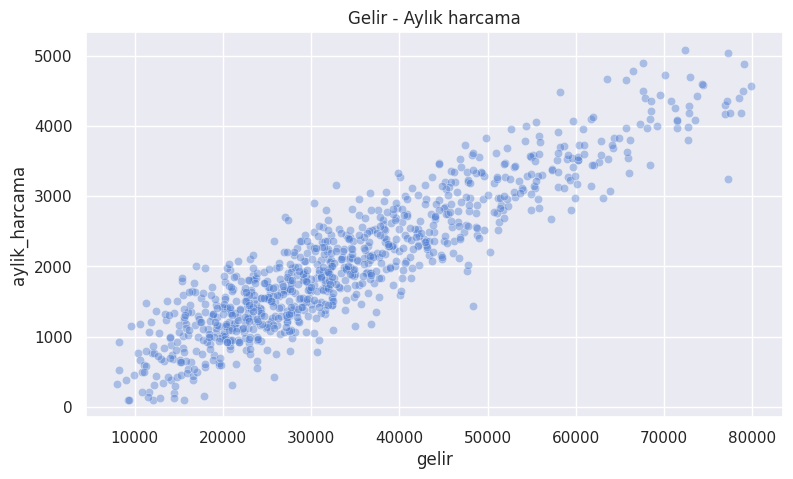

Pearson r = 0.92, p = 0.0000


In [25]:
# gelir ile harcama ilişkisine yakından bakış (uç değerler hariç)
normal_gelir = musteriler[musteriler["gelir"] <= ust]
sns.scatterplot(data=normal_gelir, x="gelir", y="aylik_harcama", alpha=0.4)
plt.title("Gelir - Aylık harcama")
plt.show()

r, p = stats.pearsonr(normal_gelir.dropna(subset=["gelir"])["gelir"],
                      normal_gelir.dropna(subset=["gelir"])["aylik_harcama"])
print(f"Pearson r = {r:.2f}, p = {p:.4f}")

## Yorumum
> 📝 _En dikkat çekici bulgu, veriye göre gelir arttıkça harcamalar da aynı oranda artıyor. Standartlar gelirle tam ilişkili._